# Part -1

# Multi-Armed Bandit: ε-Greedy vs UCB
10 arms · Gaussian rewards · 2000 steps · 1000 runs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Bandit Environment (Gymnasium-style API)

In [6]:
class BanditEnv:
    """
    10-arm Gaussian bandit following the Gymnasium API.
    Each arm's true mean is drawn from N(0,1) at reset.
    Reward noise std = 1.0.
    """
    def __init__(self, k=10, reward_std=1.0, seed=None):
        self.k = k
        self.reward_std = reward_std
        self.rng = np.random.default_rng(seed)

    def reset(self):
        """Sample new true means; return initial observation (zeros)."""
        self.q_star = self.rng.normal(0, 1, self.k)   # true arm means
        self.optimal_action = int(np.argmax(self.q_star))
        return np.zeros(self.k)                        # observation

    def step(self, action):
        """Pull arm `action`; return (obs, reward, terminated, truncated, info)."""
        reward = self.rng.normal(self.q_star[action], self.reward_std)
        obs    = np.zeros(self.k)
        info   = {"optimal_action": self.optimal_action}
        return obs, reward, False, False, info

## 2. Agents

In [7]:
class EpsilonGreedy:
    def __init__(self, k, epsilon):
        self.k, self.epsilon = k, epsilon

    def reset(self):
        self.Q = np.zeros(self.k)
        self.N = np.zeros(self.k, dtype=int)

    def select_action(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.k)
        return int(np.argmax(self.Q))

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


class UCB:
    def __init__(self, k, c):
        self.k, self.c = k, c

    def reset(self):
        self.Q = np.zeros(self.k)
        self.N = np.zeros(self.k, dtype=int)
        self.t = 0

    def select_action(self):
        self.t += 1
        # Pull untried arms first
        untried = np.where(self.N == 0)[0]
        if len(untried):
            return int(untried[0])
        scores = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        return int(np.argmax(scores))

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

## 3. Experiment Runner

In [8]:
def run_experiment(agent, n_runs=1000, n_steps=2000, k=10, seed=42):
    """
    Returns:
        avg_rewards  : (n_steps,)  mean reward across runs
        pct_optimal  : (n_steps,)  fraction of optimal actions across runs
    """
    env = BanditEnv(k=k, seed=seed)
    all_rewards = np.zeros((n_runs, n_steps))
    all_optimal = np.zeros((n_runs, n_steps))

    for run in range(n_runs):
        env.reset()
        agent.reset()
        for t in range(n_steps + 1):
            action = agent.select_action()
            _, reward, _, _, info = env.step(action)
            agent.update(action, reward)
            all_rewards[run, t] = reward
            all_optimal[run, t] = int(action == info["optimal_action"])

    return all_rewards.mean(axis=0), all_optimal.mean(axis=0) * 100

## 4. Run All Parameter Settings

In [9]:
K, N_RUNS, N_STEPS = 10, 1000, 2000

# ε-Greedy configs
epsilons = [0.01, 0.1, 0.2]
eps_results = {}
for eps in epsilons:
    print(f"Running ε-greedy ε={eps}...")
    agent = EpsilonGreedy(K, eps)
    eps_results[eps] = run_experiment(agent, N_RUNS, N_STEPS, K)

# UCB configs
c_values = [0.5, 1.0, 2.0]
ucb_results = {}
for c in c_values:
    print(f"Running UCB c={c}...")
    agent = UCB(K, c)
    ucb_results[c] = run_experiment(agent, N_RUNS, N_STEPS, K)

print("Done!")

Running ε-greedy ε=0.01...


IndexError: index 2000 is out of bounds for axis 1 with size 2000

## 5. Plot Results

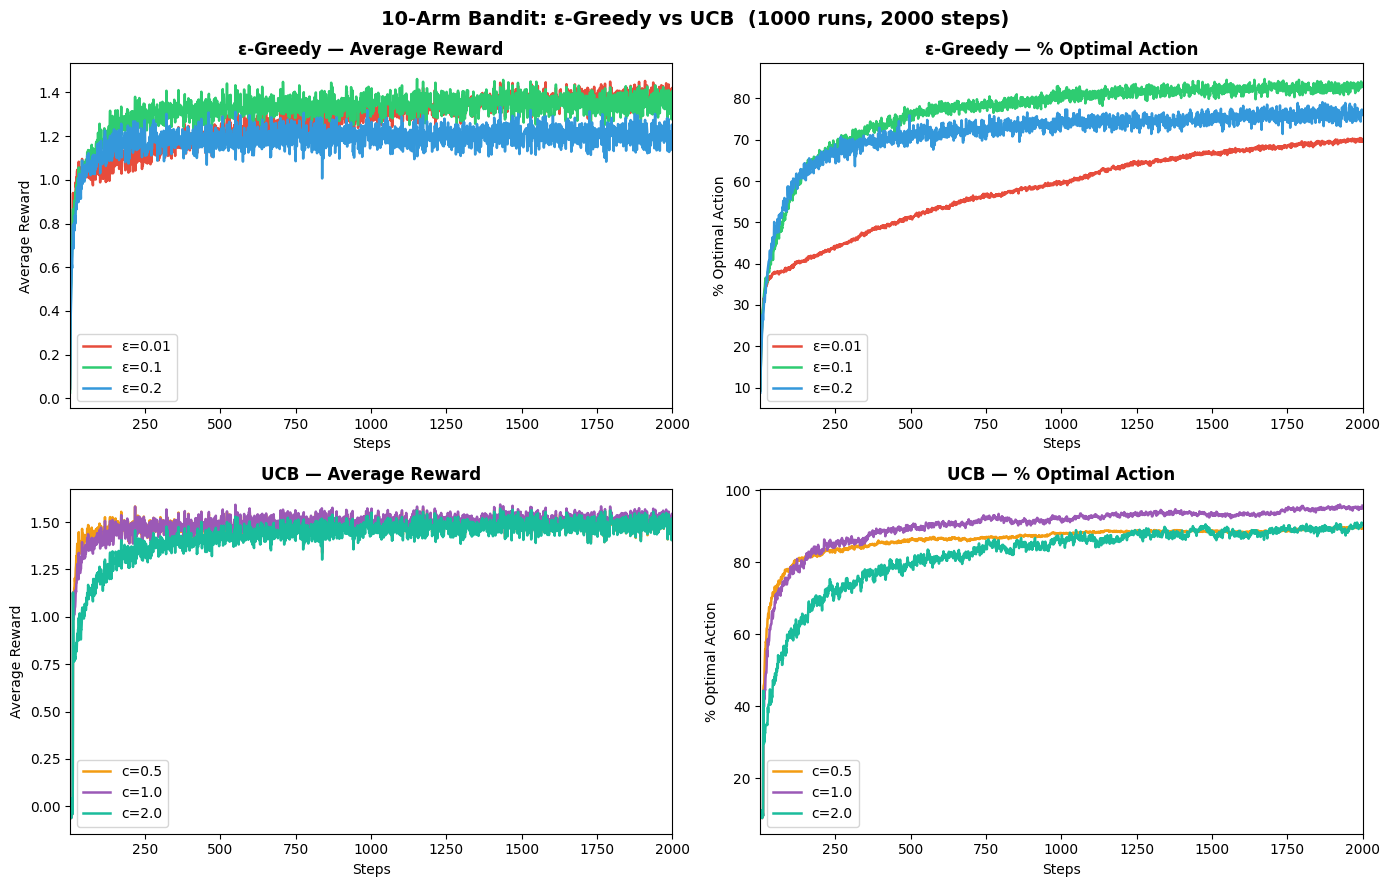

In [23]:
steps = np.arange(1, N_STEPS + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

eps_colors = ['#e74c3c', '#2ecc71', '#3498db']
ucb_colors = ['#f39c12', '#9b59b6', '#1abc9c']

# ── ε-Greedy: Average Reward ──────────────────────────────────────────────
ax = axes[0, 0]
for eps, color in zip(epsilons, eps_colors):
    avg_r, _ = eps_results[eps]
    ax.plot(steps, avg_r, color=color, lw=1.8, label=f'ε={eps}')
ax.set_title('ε-Greedy — Average Reward', fontweight='bold')
ax.set_xlabel('Steps'); ax.set_ylabel('Average Reward')
ax.legend(); ax.set_xlim(1, N_STEPS)

# ── ε-Greedy: % Optimal Action ────────────────────────────────────────────
ax = axes[0, 1]
for eps, color in zip(epsilons, eps_colors):
    _, pct_opt = eps_results[eps]
    ax.plot(steps, pct_opt, color=color, lw=1.8, label=f'ε={eps}')
ax.set_title('ε-Greedy — % Optimal Action', fontweight='bold')
ax.set_xlabel('Steps'); ax.set_ylabel('% Optimal Action')
ax.legend(); ax.set_xlim(1, N_STEPS)

# ── UCB: Average Reward ───────────────────────────────────────────────────
ax = axes[1, 0]
for c, color in zip(c_values, ucb_colors):
    avg_r, _ = ucb_results[c]
    ax.plot(steps, avg_r, color=color, lw=1.8, label=f'c={c}')
ax.set_title('UCB — Average Reward', fontweight='bold')
ax.set_xlabel('Steps'); ax.set_ylabel('Average Reward')
ax.legend(); ax.set_xlim(1, N_STEPS)

# ── UCB: % Optimal Action ─────────────────────────────────────────────────
ax = axes[1, 1]
for c, color in zip(c_values, ucb_colors):
    _, pct_opt = ucb_results[c]
    ax.plot(steps, pct_opt, color=color, lw=1.8, label=f'c={c}')
ax.set_title('UCB — % Optimal Action', fontweight='bold')
ax.set_xlabel('Steps'); ax.set_ylabel('% Optimal Action')
ax.legend(); ax.set_xlim(1, N_STEPS)

plt.suptitle('10-Arm Bandit: ε-Greedy vs UCB  (1000 runs, 2000 steps)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Head-to-Head Comparison (Best of Each)

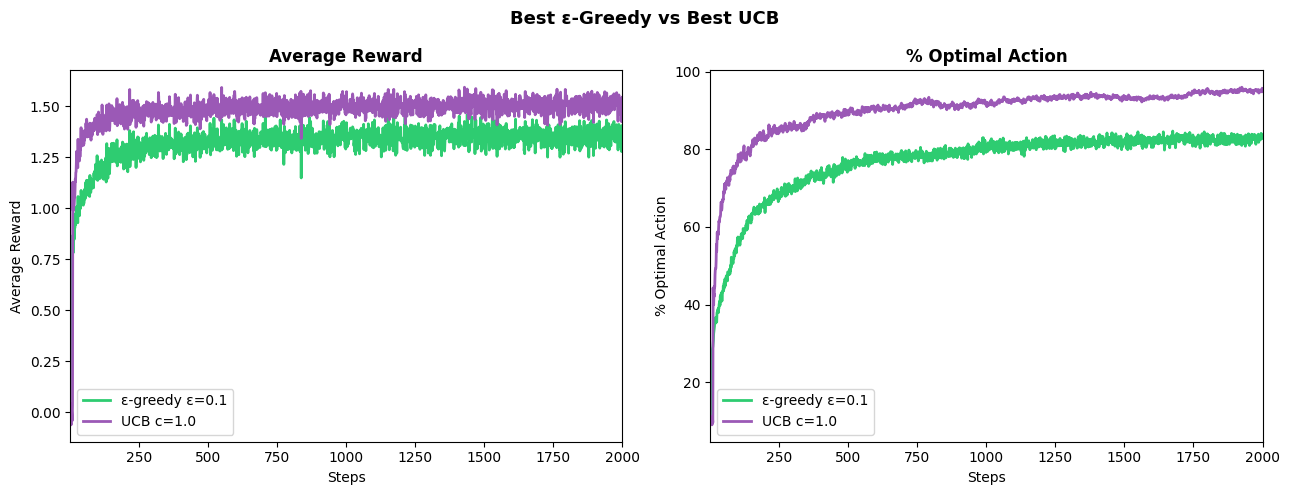

Final avg reward  — ε-greedy ε=0.1: 1.359
Final avg reward  — UCB      c=1.0:   1.511
Final % optimal   — ε-greedy ε=0.1: 82.8%
Final % optimal   — UCB      c=1.0:   95.1%


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

best_eps = 0.1
best_c   = 1.0

eps_r, eps_p = eps_results[best_eps]
ucb_r, ucb_p = ucb_results[best_c]

axes[0].plot(steps, eps_r, color='#2ecc71', lw=2, label=f'ε-greedy ε={best_eps}')
axes[0].plot(steps, ucb_r, color='#9b59b6', lw=2, label=f'UCB c={best_c}')
axes[0].set_title('Average Reward', fontweight='bold')
axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average Reward')
axes[0].legend(); axes[0].set_xlim(1, N_STEPS)

axes[1].plot(steps, eps_p, color='#2ecc71', lw=2, label=f'ε-greedy ε={best_eps}')
axes[1].plot(steps, ucb_p, color='#9b59b6', lw=2, label=f'UCB c={best_c}')
axes[1].set_title('% Optimal Action', fontweight='bold')
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal Action')
axes[1].legend(); axes[1].set_xlim(1, N_STEPS)

plt.suptitle(f'Best ε-Greedy vs Best UCB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Final avg reward  — ε-greedy ε={best_eps}: {eps_r[-100:].mean():.3f}")
print(f"Final avg reward  — UCB      c={best_c}:   {ucb_r[-100:].mean():.3f}")
print(f"Final % optimal   — ε-greedy ε={best_eps}: {eps_p[-100:].mean():.1f}%")
print(f"Final % optimal   — UCB      c={best_c}:   {ucb_p[-100:].mean():.1f}%")

# Part - 2 

# Gymnasium Environments: FrozenLake-v1 & Taxi-v3

This notebook explores two classic RL environments through the lens of the **MDP tuple (S, A, R, P, γ)**,
inspects their spaces, and benchmarks a random-policy agent.

---

### MDP → Gymnasium API Mapping

| MDP Component | Symbol | Gymnasium Equivalent |
|---|---|---|
| State space | S | `env.observation_space` |
| Action space | A | `env.action_space` |
| Reward function | R | scalar returned by `env.step()` |
| Transition probabilities | P | `env.P[state][action]` (model-based envs) |
| Discount factor | γ | set by the agent/algorithm (not stored in env) |
| Initial state distribution | ρ₀ | `env.reset()` |
| Terminal states | — | `terminated` flag from `env.step()` |

## 1. Setup

In [25]:
# Install if needed
# !pip install gymnasium numpy pandas matplotlib

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from abc import ABC, abstractmethod
from typing import Any

print(f"Gymnasium version: {gym.__version__}")

Gymnasium version: 1.2.3


## 2. Base Agent Interface

All agents implement a common interface so they can be swapped without changing the training loop.

In [ ]:
class BaseAgent(ABC):
    """Abstract base class for all agents."""

    def __init__(self, env: gym.Env, gamma: float = 0.99):
        self.env = env
        self.gamma = gamma  # γ — discount factor (agent-side MDP component)

    @abstractmethod
    def select_action(self, observation: Any) -> Any:
        """Map observation (∈ S) to action (∈ A)."""
        ...

    def run_episode(self, seed: int | None = None) -> dict:
        """
        Execute one full episode.
        Returns a dict with total_reward, steps, and discounted_return.
        """
        obs, _ = self.env.reset(seed=seed)   # ρ₀ — initial state
        total_reward = 0.0
        discounted_return = 0.0
        steps = 0
        terminated = truncated = False

        while not (terminated or truncated):
            action = self.select_action(obs)            # π(s)
            obs, reward, done, info = self.env.step(action)  # P, R
            total_reward += reward
            discounted_return += (self.gamma ** steps) * reward
            steps += 1

        return {"total_reward": total_reward,
                "discounted_return": discounted_return,
                "steps": steps}

    def evaluate(self, n_episodes: int = 500, seed: int = 42) -> pd.DataFrame:
        """Run n_episodes and return a DataFrame of results."""
        results = [self.run_episode(seed=seed + i) for i in range(n_episodes)]
        return pd.DataFrame(results)


class RandomAgent(BaseAgent):
    """Selects actions uniformly at random from the action space."""

    def select_action(self, observation: Any) -> Any:
        return self.env.action_space.sample()  # Uniform over A

## 3. Space Inspector Helper

A utility function to print observation and action space details.

In [27]:
def inspect_spaces(env_id: str) -> gym.Env:
    """Make an environment and print its MDP space details."""
    env = gym.make(env_id)
    obs_space = env.observation_space
    act_space = env.action_space

    print(f"{'='*50}")
    print(f"  Environment : {env_id}")
    print(f"{'='*50}")

    # --- Observation space (S) ---
    print(f"\n[S] Observation Space : {type(obs_space).__name__}")
    if isinstance(obs_space, gym.spaces.Discrete):
        print(f"    |S| = {obs_space.n}  (states 0 … {obs_space.n - 1})")
        print(f"    Type: Discrete (tabular-friendly)")
    elif isinstance(obs_space, gym.spaces.Box):
        print(f"    Shape : {obs_space.shape}")
        print(f"    dtype : {obs_space.dtype}")
        print(f"    Low   : {obs_space.low}")
        print(f"    High  : {obs_space.high}")
        print(f"    Type: Continuous (needs function approximation)")

    # --- Action space (A) ---
    print(f"\n[A] Action Space      : {type(act_space).__name__}")
    if isinstance(act_space, gym.spaces.Discrete):
        print(f"    |A| = {act_space.n}  (actions 0 … {act_space.n - 1})")
        print(f"    Type: Discrete")
    elif isinstance(act_space, gym.spaces.Box):
        print(f"    Shape : {act_space.shape}")
        print(f"    Low   : {act_space.low}")
        print(f"    High  : {act_space.high}")
        print(f"    Type: Continuous")

    # --- Transition model (P) ---
    if hasattr(env.unwrapped, 'P'):
        P = env.unwrapped.P
        print(f"\n[P] Transition Model  : Available (model-based env)")
        s0 = next(iter(P))
        a0 = next(iter(P[s0]))
        print(f"    P[{s0}][{a0}] = {P[s0][a0]}")
        print(f"    Format: [(prob, next_state, reward, terminated), ...]")
    else:
        print(f"\n[P] Transition Model  : Not exposed (model-free env)")

    print(f"\n[γ] Discount Factor   : Set by agent (default 0.99)")
    print()
    return env

## 4. FrozenLake-v1

A 4×4 grid where the agent navigates from S(tart) to G(oal) avoiding H(oles).
- **S**: 16 discrete states (grid cells)
- **A**: 4 actions {Left, Down, Right, Up}
- **R**: +1 on reaching the goal, 0 elsewhere
- **P**: Stochastic — wind can push the agent sideways (is_slippery=True)

In [28]:
fl_env = inspect_spaces("FrozenLake-v1")

  Environment : FrozenLake-v1

[S] Observation Space : Discrete
    |S| = 16  (states 0 … 15)
    Type: Discrete (tabular-friendly)

[A] Action Space      : Discrete
    |A| = 4  (actions 0 … 3)
    Type: Discrete

[P] Transition Model  : Available (model-based env)
    P[0][0] = [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 0, 0, False), (0.33333333333333337, 4, 0, False)]
    Format: [(prob, next_state, reward, terminated), ...]

[γ] Discount Factor   : Set by agent (default 0.99)



In [29]:
# Visualize the FrozenLake grid
fl_env_render = gym.make("FrozenLake-v1", render_mode="ansi")
fl_env_render.reset()
print(fl_env_render.render())
fl_env_render.close()

# Legend
print("Legend: S=Start, F=Frozen(safe), H=Hole(fall in!), G=Goal")
print("Actions: 0=Left, 1=Down, 2=Right, 3=Up")


SFFF
FHFH
FFFH
HFFG

Legend: S=Start, F=Frozen(safe), H=Hole(fall in!), G=Goal
Actions: 0=Left, 1=Down, 2=Right, 3=Up


In [30]:
# Inspect one step of the MDP
obs, _ = fl_env.reset(seed=0)
print(f"Initial state (obs): {obs}  →  grid cell ({obs//4}, {obs%4})")

action = 2  # Right
next_obs, reward, terminated, truncated, info = fl_env.step(action)
print(f"Action taken        : {action} (Right)")
print(f"Next state          : {next_obs}")
print(f"Reward (R)          : {reward}")
print(f"Terminated          : {terminated}")
print(f"Info                : {info}")

Initial state (obs): 0  →  grid cell (0, 0)
Action taken        : 2 (Right)
Next state          : 4
Reward (R)          : 0
Terminated          : False
Info                : {'prob': 0.33333333333333337}


In [31]:
# Run random agent on FrozenLake
fl_agent = RandomAgent(fl_env, gamma=0.99)
fl_results = fl_agent.evaluate(n_episodes=1000)

success_rate = fl_results["total_reward"].mean()
avg_steps = fl_results["steps"].mean()
avg_return = fl_results["discounted_return"].mean()

print("FrozenLake-v1 — Random Agent (1000 episodes)")
print(f"  Success rate        : {success_rate:.1%}")
print(f"  Avg steps/episode   : {avg_steps:.1f}")
print(f"  Avg discounted G    : {avg_return:.4f}")
fl_results.describe()

FrozenLake-v1 — Random Agent (1000 episodes)
  Success rate        : 1.9%
  Avg steps/episode   : 8.0
  Avg discounted G    : 0.0169


,total_reward,discounted_return,steps
count,1000.000000,1000.000000,1000.000000
mean,0.019000,0.016901,8.016000
std,0.136593,0.121676,5.973058
min,0.000000,0.000000,2.000000
25%,0.000000,0.000000,4.000000
50%,0.000000,0.000000,6.000000
75%,0.000000,0.000000,10.000000
max,1.000000,0.950990,46.000000


## 5. Taxi-v3

A 5×5 grid taxi that must pick up and drop off a passenger.
- **S**: 500 discrete states (taxi pos × passenger loc × destination)
- **A**: 6 actions {South, North, East, West, Pickup, Dropoff}
- **R**: −1 per step, +20 for successful dropoff, −10 for illegal pickup/dropoff
- **P**: Deterministic

In [32]:
taxi_env = inspect_spaces("Taxi-v3")

  Environment : Taxi-v3

[S] Observation Space : Discrete
    |S| = 500  (states 0 … 499)
    Type: Discrete (tabular-friendly)

[A] Action Space      : Discrete
    |A| = 6  (actions 0 … 5)
    Type: Discrete

[P] Transition Model  : Available (model-based env)
    P[0][0] = [(1.0, 100, -1, False)]
    Format: [(prob, next_state, reward, terminated), ...]

[γ] Discount Factor   : Set by agent (default 0.99)



In [33]:
# Visualize Taxi start state
taxi_render = gym.make("Taxi-v3", render_mode="ansi")
taxi_render.reset(seed=7)
print(taxi_render.render())
taxi_render.close()

print("Actions: 0=South, 1=North, 2=East, 3=West, 4=Pickup, 5=Dropoff")
print("Decode state: gym.make('Taxi-v3').unwrapped.decode(state)")

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Actions: 0=South, 1=North, 2=East, 3=West, 4=Pickup, 5=Dropoff
Decode state: gym.make('Taxi-v3').unwrapped.decode(state)


In [ ]:
# Decode a Taxi state into components
obs, _ = taxi_env.reset(seed=7)
taxi_row, taxi_col, pass_idx = taxi_env.unwrapped.decode(obs)
locs = ['R', 'G', 'Y', 'B']
print(f"State {obs} decoded:")
print(f"  Taxi position       : row={taxi_row}, col={taxi_col}")
print(f"  Passenger location  : {locs[pass_idx]} (idx={pass_idx})")
print(f"  Destination         : {locs[dest_idx]} (idx={dest_idx})")

State 309 decoded:
  Taxi position       : row=3, col=0
  Passenger location  : Y (idx=2)
  Destination         : G (idx=1)


In [35]:
# Run random agent on Taxi
taxi_agent = RandomAgent(taxi_env, gamma=0.99)
taxi_results = taxi_agent.evaluate(n_episodes=500)

print("Taxi-v3 — Random Agent (500 episodes)")
print(f"  Avg total reward    : {taxi_results['total_reward'].mean():.1f}")
print(f"  Avg steps/episode   : {taxi_results['steps'].mean():.1f}")
print(f"  Avg discounted G    : {taxi_results['discounted_return'].mean():.4f}")
taxi_results.describe()

Taxi-v3 — Random Agent (500 episodes)
  Avg total reward    : -772.3
  Avg steps/episode   : 196.9
  Avg discounted G    : -336.6917


,total_reward,discounted_return,steps
count,500.000000,500.000000,500.000000
mean,-772.292000,-336.691705,196.910000
std,98.785687,38.315118,17.985574
min,-974.000000,-436.873783,34.000000
25%,-830.000000,-359.301150,200.000000
50%,-785.000000,-339.916375,200.000000
75%,-731.000000,-319.498182,200.000000
max,-126.000000,-111.073491,200.000000


## 6. Side-by-Side Performance Comparison

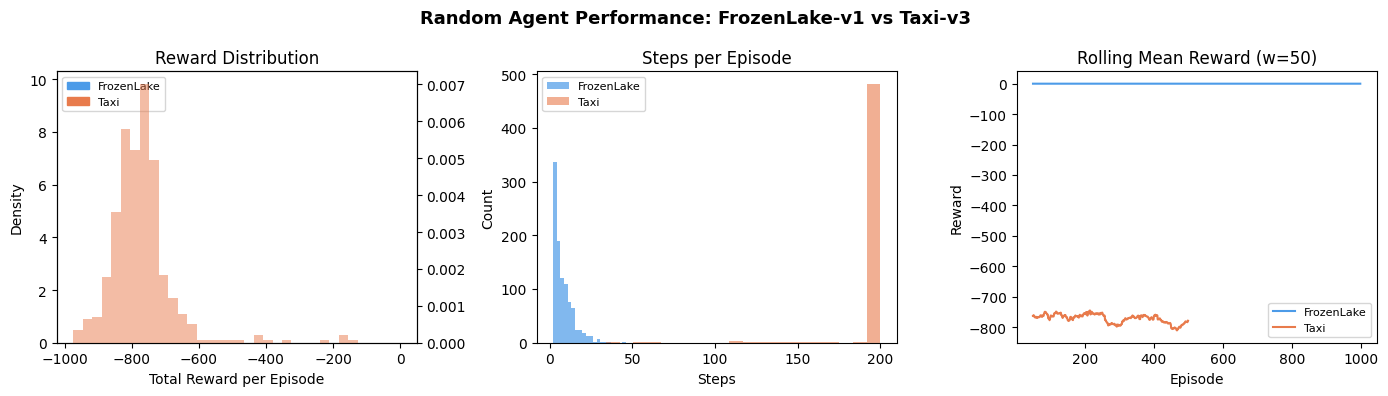

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Random Agent Performance: FrozenLake-v1 vs Taxi-v3", fontsize=13, fontweight='bold')

colors = {'FrozenLake': '#4C9BE8', 'Taxi': '#E87B4C'}

# --- Plot 1: Reward distribution ---
axes[0].hist(fl_results['total_reward'], bins=10, alpha=0.7,
             color=colors['FrozenLake'], label='FrozenLake', density=True)
axes[0].set_title('Reward Distribution')
axes[0].set_xlabel('Total Reward per Episode')
axes[0].set_ylabel('Density')

ax0b = axes[0].twinx()
ax0b.hist(taxi_results['total_reward'], bins=30, alpha=0.5,
          color=colors['Taxi'], label='Taxi', density=True)
ax0b.set_ylabel('')

# Combined legend
p1 = mpatches.Patch(color=colors['FrozenLake'], label='FrozenLake')
p2 = mpatches.Patch(color=colors['Taxi'], label='Taxi')
axes[0].legend(handles=[p1, p2], loc='upper left', fontsize=8)

# --- Plot 2: Steps per episode ---
axes[1].hist(fl_results['steps'], bins=20, alpha=0.7,
             color=colors['FrozenLake'], label='FrozenLake')
axes[1].hist(taxi_results['steps'], bins=20, alpha=0.6,
             color=colors['Taxi'], label='Taxi')
axes[1].set_title('Steps per Episode')
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

# --- Plot 3: Rolling mean reward ---
window = 50
fl_roll = fl_results['total_reward'].rolling(window).mean()
taxi_roll = taxi_results['total_reward'].rolling(window).mean()
axes[2].plot(fl_roll.values, color=colors['FrozenLake'], label='FrozenLake')
axes[2].plot(taxi_roll.values, color=colors['Taxi'], label='Taxi')
axes[2].set_title(f'Rolling Mean Reward (w={window})')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Reward')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [37]:
# Summary table
summary = pd.DataFrame({
    'Environment':    ['FrozenLake-v1',        'Taxi-v3'],
    '|S|':           [16,                       500],
    '|A|':           [4,                        6],
    'Space Type':    ['Discrete / Discrete',    'Discrete / Discrete'],
    'Stochastic':    ['Yes (is_slippery=True)',  'No'],
    'Avg Reward':    [f"{fl_results['total_reward'].mean():.3f}",
                      f"{taxi_results['total_reward'].mean():.1f}"],
    'Avg Steps':     [f"{fl_results['steps'].mean():.1f}",
                      f"{taxi_results['steps'].mean():.1f}"],
    'Avg G (γ=.99)': [f"{fl_results['discounted_return'].mean():.4f}",
                      f"{taxi_results['discounted_return'].mean():.2f}"],
}).set_index('Environment')

print("Summary — Random Policy Benchmark")
summary

Summary — Random Policy Benchmark


,|S|,|A|,Space Type,Stochastic,Avg Reward,Avg Steps,Avg G (γ=.99)
Environment,,,,,,,
FrozenLake-v1,16,4,Discrete / Discrete,Yes (is_slippery=True),0.019,8.0,0.0169
Taxi-v3,500,6,Discrete / Discrete,No,-772.3,196.9,-336.69


## 7. Cleanup

In [38]:
fl_env.close()
taxi_env.close()
print("Environments closed.")

Environments closed.


## 8. Key Takeaways

| Topic | FrozenLake-v1 | Taxi-v3 |
|---|---|---|
| MDP complexity | Small (16 states) | Larger (500 states) |
| Stochasticity | High (wind) | None |
| Reward sparsity | Very sparse (+1 only at goal) | Dense (−1 every step) |
| Random policy success | ~1–3% | Negative reward (−200 avg) |
| Transition model (P) | Exposed | Exposed |
| Best RL approach | Value iteration / Q-learning | Q-learning / SARSA |

Both environments expose `env.P` making them suitable for **model-based** methods (value/policy iteration)
in addition to model-free methods. The `BaseAgent` → `RandomAgent` hierarchy makes it easy to add
`QLearningAgent`, `SARSAAgent`, etc. by overriding only `select_action()`.